In [5]:
import sys
import warnings
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings("ignore", category=UserWarning)

for env_path in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.cwd().parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path)
        print("Loaded .env from:", env_path.resolve())
        break


def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ETL").is_dir():
            return p
    return cwd.parent.parent


ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ETL.gnn_db_pipeline.config import TARGET_DB, TGT_CHANGED_HOLDINGS
from ETL.gnn_db_pipeline.db_connector import ConfigurablePostgresHandler

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
print("Project root:", ROOT)
print("Target DB:", TARGET_DB)

handler = ConfigurablePostgresHandler(TARGET_DB)
handler.connect()


2026-04-18 19:17:36 - ETL_Pipeline - INFO - Connected to PostgreSQL: postgres@127.0.0.1:5432/13FGNN


Loaded .env from: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\.env
Project root: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market
Target DB: 13FGNN


True

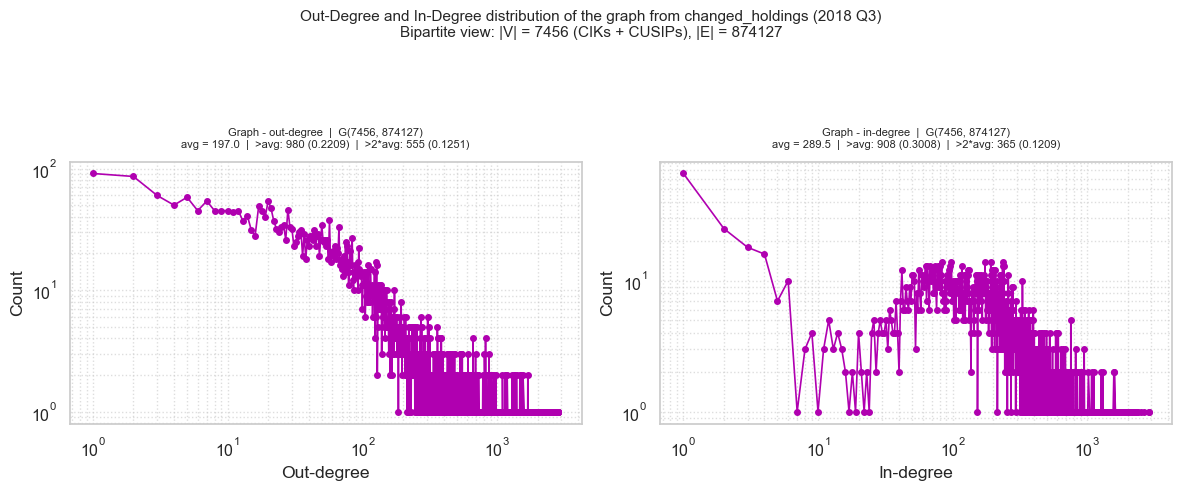

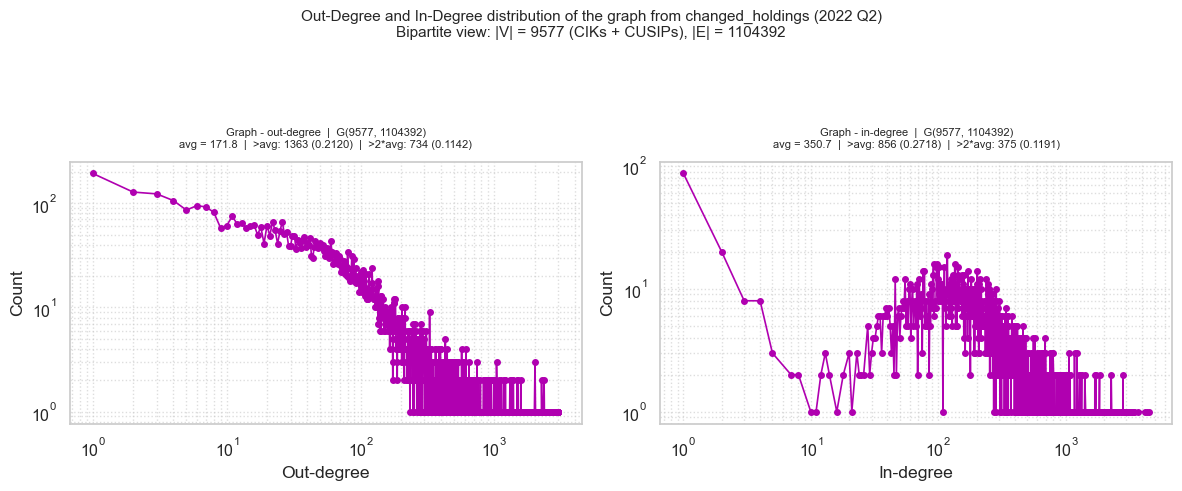

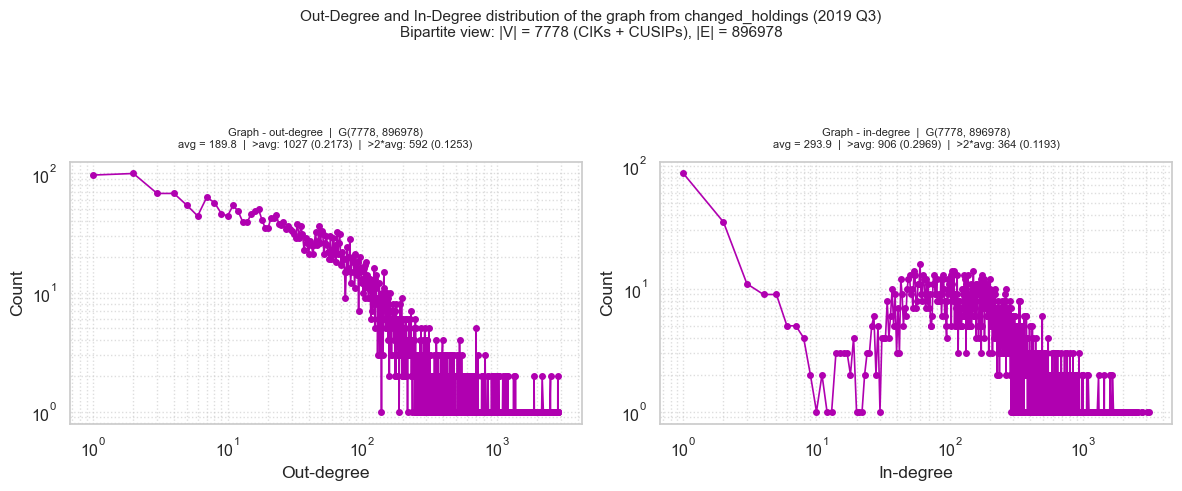

In [7]:
PURPLE = "#B000B0"


def load_degree_series(handler, year: int, quarter: int) -> Tuple[pd.Series, pd.Series]:
    """Per-CUSIP in-degree (distinct CIKs); per-CIK out-degree (distinct CUSIPs)."""
    q_in = f"""
    SELECT COUNT(DISTINCT cik) AS degree_in
    FROM {TGT_CHANGED_HOLDINGS}
    WHERE year = %s AND quarter = %s
    GROUP BY cusip
    """
    q_out = f"""
    SELECT COUNT(DISTINCT cusip) AS degree_out
    FROM {TGT_CHANGED_HOLDINGS}
    WHERE year = %s AND quarter = %s
    GROUP BY cik
    """
    d_in = handler.query(q_in, (year, quarter))["degree_in"]
    d_out = handler.query(q_out, (year, quarter))["degree_out"]
    return d_in, d_out


def _edge_count(handler, year: int, quarter: int) -> int:
    q = f"SELECT COUNT(*) AS n FROM {TGT_CHANGED_HOLDINGS} WHERE year = %s AND quarter = %s"
    return int(handler.query(q, (year, quarter)).iloc[0, 0])


def _degree_frequency(deg: pd.Series) -> pd.DataFrame:
    if deg is None or deg.empty:
        return pd.DataFrame(columns=["k", "count"])
    vc = deg.astype(int).value_counts().sort_index()
    return pd.DataFrame({"k": vc.index.to_numpy(), "count": vc.values.astype(int)})


def _side_caption(side: str, n_total: int, m: int, n_side: int, deg: pd.Series) -> str:
    if n_side == 0 or m == 0:
        return f"Graph - {side}-degree\nG({n_total}, {m}) (empty)"
    avg = m / n_side
    gt_avg = int((deg > avg).sum())
    p_avg = gt_avg / n_side
    gt2 = int((deg > 2 * avg).sum())
    p2 = gt2 / n_side
    line1 = f"Graph - {side}-degree  |  G({n_total}, {m})"
    line2 = (
        f"avg = {avg:.1f}  |  >avg: {gt_avg} ({p_avg:.4f})  |  >2*avg: {gt2} ({p2:.4f})"
    )
    return f"{line1}\n{line2}"


def _plot_loglog_degree(ax, deg: pd.Series, side: str, n_total: int, m: int, n_side: int):
    freq = _degree_frequency(deg)
    freq = freq.loc[(freq["k"] > 0) & (freq["count"] > 0)]
    if freq.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(_side_caption(side, n_total, m, n_side, deg), fontsize=8, pad=10)
        return
    ax.plot(
        freq["k"],
        freq["count"],
        color=PURPLE,
        marker="o",
        markersize=4,
        linewidth=1.2,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Out-degree" if side == "out" else "In-degree")
    ax.set_ylabel("Count")
    ax.grid(True, which="both", linestyle=":", alpha=0.65)
    ax.set_title(_side_caption(side, n_total, m, n_side, deg), fontsize=8, pad=10)


def plot_quarter_degree_distributions(handler, year: int, quarter: int) -> None:
    deg_in, deg_out = load_degree_series(handler, year, quarter)
    m = _edge_count(handler, year, quarter)
    n_cik = int(deg_out.shape[0])
    n_cusip = int(deg_in.shape[0])
    n_total = n_cik + n_cusip

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    _plot_loglog_degree(axes[0], deg_out, "out", n_total, m, n_cik)
    _plot_loglog_degree(axes[1], deg_in, "in", n_total, m, n_cusip)

    period = f"{year} Q{quarter}"
    fig.suptitle(
        f"Out-Degree and In-Degree distribution of the graph from changed_holdings ({period})\n"
        f"Bipartite view: |V| = {n_total} (CIKs + CUSIPs), |E| = {m}",
        fontsize=11,
    )
    plt.tight_layout(rect=(0, 0, 1, 0.88))
    plt.show()


quarters_plot = [(2018, 3), (2022, 2) ,(2019,3)]
for y, q in quarters_plot:
    plot_quarter_degree_distributions(handler, y, q)

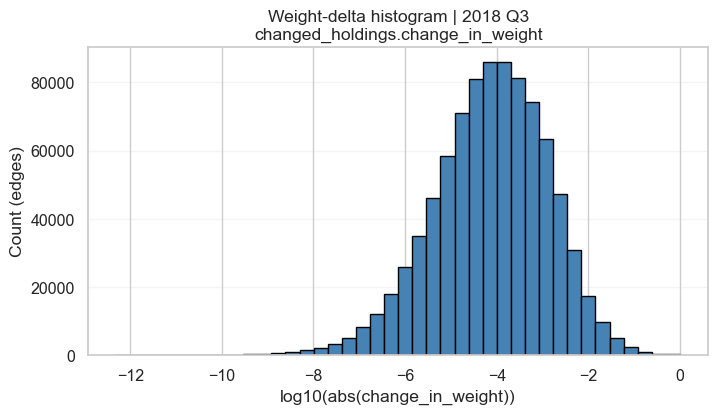

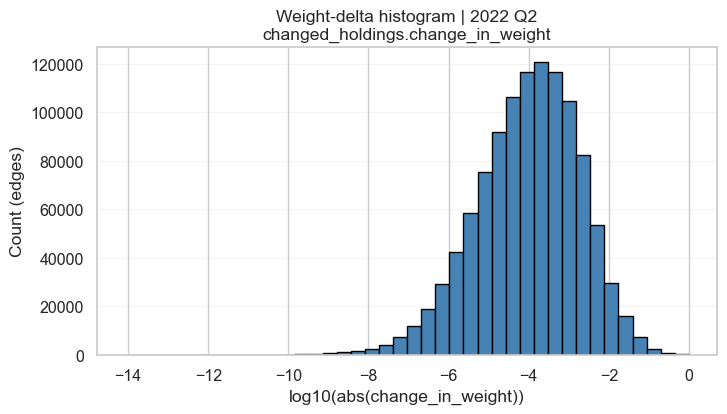

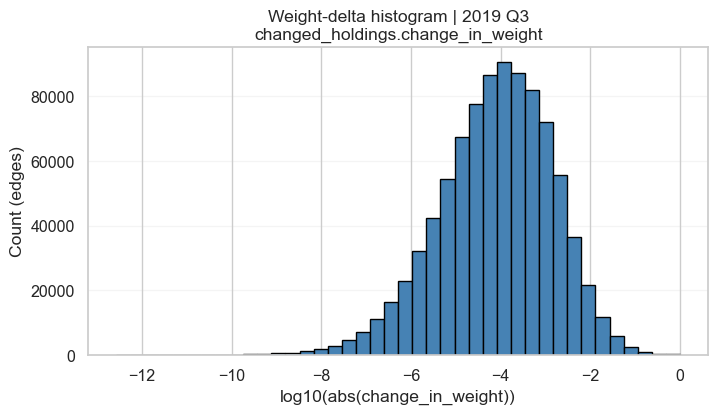

In [15]:
def plot_edge_weight_histograms(handler, quarters):
    """Histogram of log10(abs(delta)) per quarter.

    `changed_holdings` has **change_in_*** columns, not portfolio `weight`
    (that lives on `normalized_holdings`). Here we use **change_in_weight**.
    """
    for year, quarter in quarters:
        q = f"""
        SELECT change_in_weight AS w
        FROM {TGT_CHANGED_HOLDINGS}
        WHERE year = %s AND quarter = %s
        """
        df = handler.query(q, (year, quarter))
        if df.empty:
            print(f"No rows for {year} Q{quarter}")
            continue

        weights = df["w"].replace(0, np.nan).dropna()
        log_abs = np.log10(np.abs(weights))

        plt.figure(figsize=(8, 4))
        plt.hist(log_abs, bins=40, color="steelblue", edgecolor="black")
        plt.xlabel("log10(abs(change_in_weight))")
        plt.ylabel("Count (edges)")
        plt.title(
            f"Weight-delta histogram | {year} Q{quarter}\n{TGT_CHANGED_HOLDINGS}.change_in_weight"
        )
        plt.grid(axis="y", alpha=0.2)
        plt.show()


plot_edge_weight_histograms(handler, quarters_plot)


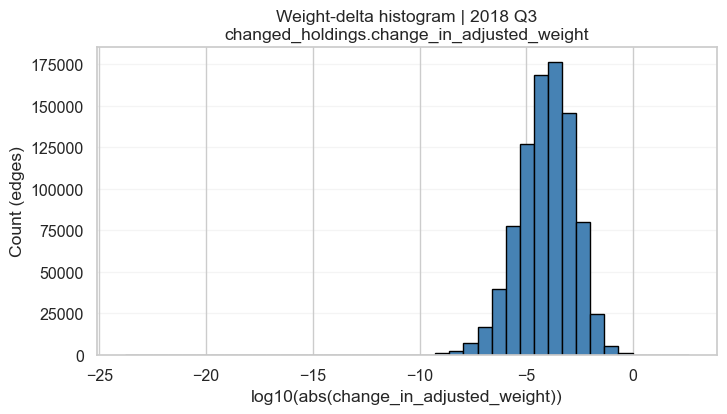

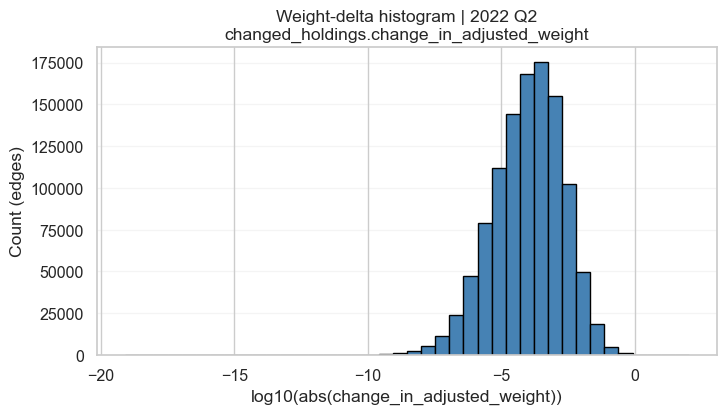

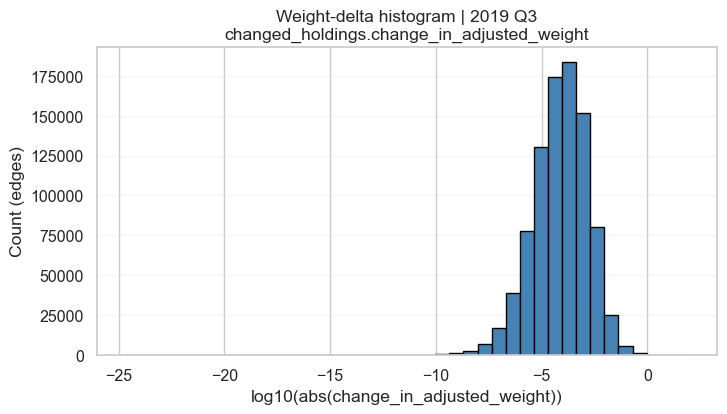

In [17]:
def plot_edge_weight_histograms(handler, quarters):
    """Histogram of log10(abs(delta)) per quarter.

    `changed_holdings` has **change_in_*** columns, not portfolio `weight`
    (that lives on `normalized_holdings`). Here we use **change_in_weight**.
    """
    for year, quarter in quarters:
        q = f"""
        SELECT change_in_adjusted_weight AS w
        FROM {TGT_CHANGED_HOLDINGS}
        WHERE year = %s AND quarter = %s
        """
        df = handler.query(q, (year, quarter))
        if df.empty:
            print(f"No rows for {year} Q{quarter}")
            continue

        weights = df["w"].replace(0, np.nan).dropna()
        log_abs = np.log10(np.abs(weights))

        plt.figure(figsize=(8, 4))
        plt.hist(log_abs, bins=40, color="steelblue", edgecolor="black")
        plt.xlabel("log10(abs(change_in_adjusted_weight))")
        plt.ylabel("Count (edges)")
        plt.title(
            f"Weight-delta histogram | {year} Q{quarter}\n{TGT_CHANGED_HOLDINGS}.change_in_adjusted_weight"
        )
        plt.grid(axis="y", alpha=0.2)
        plt.show()


plot_edge_weight_histograms(handler, quarters_plot)
